In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [2]:
# imports
import numpy as np
import tifffile as tiff
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt

In [10]:
# loading the data set
tiff_path = r'/path/to/your/file.tif'
img = tiff.imread(tiff_path)

print("Original TIFF shape:", img.shape)

spectra_data = np.moveaxis(img, spectral_axis, 1)

print("Reordered cube shape (nx, nspec, ny):", spectra_data.shape)

wavenumber = None

In [4]:
# remove cosmic rays for ONE spectrum
def clean_spectrum(spectrum, max_width=2):
    y = spectrum.copy()
    cosmic_mask = np.zeros_like(y, dtype=bool)

    while True:
        peaks, _ = find_peaks(y)

        if len(peaks) == 0:
            break

        peak_heights = y[peaks]
        highest_peak_idx = peaks[np.argmax(peak_heights)]

        widths = peak_widths(y, [highest_peak_idx], rel_height=0.5)[0]
        width = widths[0]

        if width > max_width:
            break

        left = highest_peak_idx - 1
        right = highest_peak_idx + 1

        cosmic_mask[highest_peak_idx] = True

        if left >= 0 and right < len(y):
            y[highest_peak_idx] = (y[left] + y[right]) / 2
        elif left >= 0:
            y[highest_peak_idx] = y[left]
        elif right < len(y):
            y[highest_peak_idx] = y[right]
        else:
            break

    return y, cosmic_mask

In [7]:
# apply function above to every spectrum
nx, nspec, ny = spectra_data.shape

cleaned_cube = np.zeros_like(spectra_data)
cosmic_mask_cube = np.zeros_like(spectra_data, dtype=bool)

for i in range(nx):
    for j in range(ny):
        spectrum = spectra_data[i, :, j]
        cleaned_spectrum, cosmic_mask = clean_spectrum(spectrum, max_width=2)
        cleaned_cube[i, :, j] = cleaned_spectrum
        cosmic_mask_cube[i, :, j] = cosmic_mask

In [8]:
# Compute max of cleaned spectrum
max_intensity_clean = np.max(cleaned_cube, axis=1)
max_index_clean = np.argmax(cleaned_cube, axis=1)

if wavenumber is not None:
    max_wavenumber_clean = wavenumber[max_index_clean]

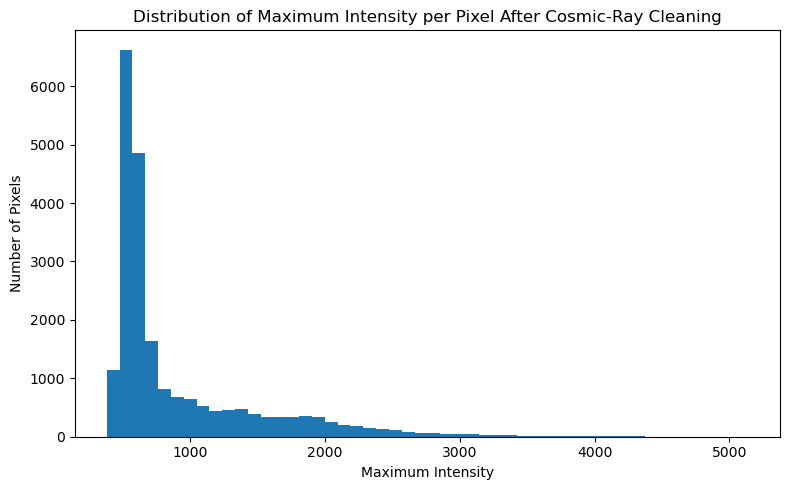

In [11]:
# histogram of max intensities after cleaning
plt.figure(figsize=(8, 5))
plt.hist(max_intensity_clean.flatten(), bins=50)
plt.xlabel("Maximum Intensity")
plt.ylabel("Number of Pixels")
plt.title("Distribution of Maximum Intensity per Pixel after Cosmic-Ray Filter")
plt.tight_layout()
plt.show()